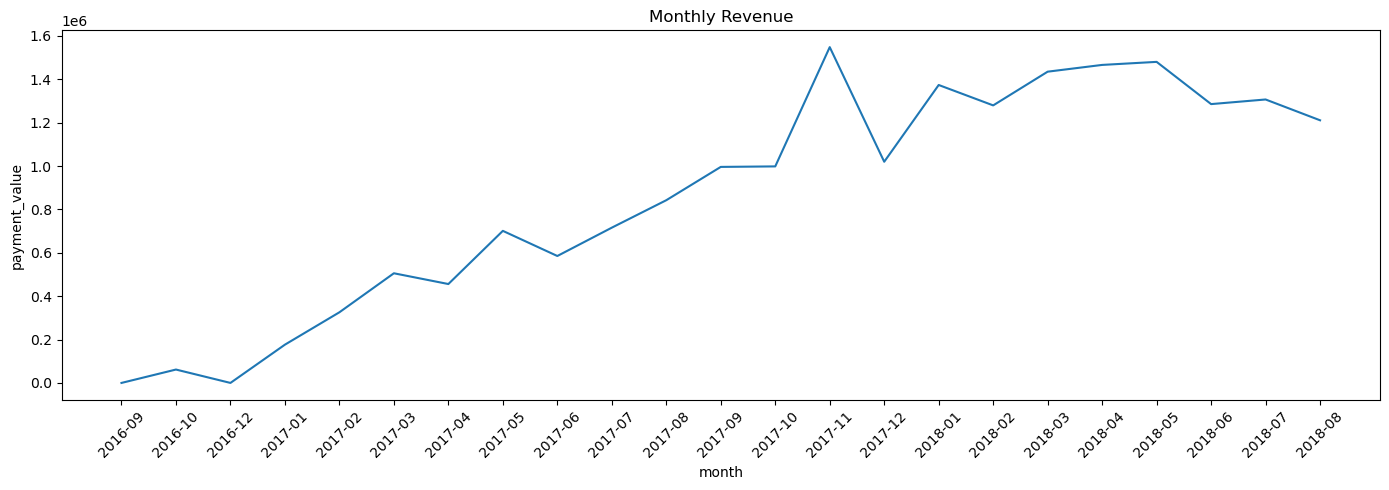

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

master = pd.read_csv('../data/cleaned/master.csv', parse_dates=['order_purchase_timestamp'])

master['month'] = master['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = master.groupby('month')['payment_value'].sum().reset_index()
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='month', y='payment_value')
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.tight_layout()
plt.show()

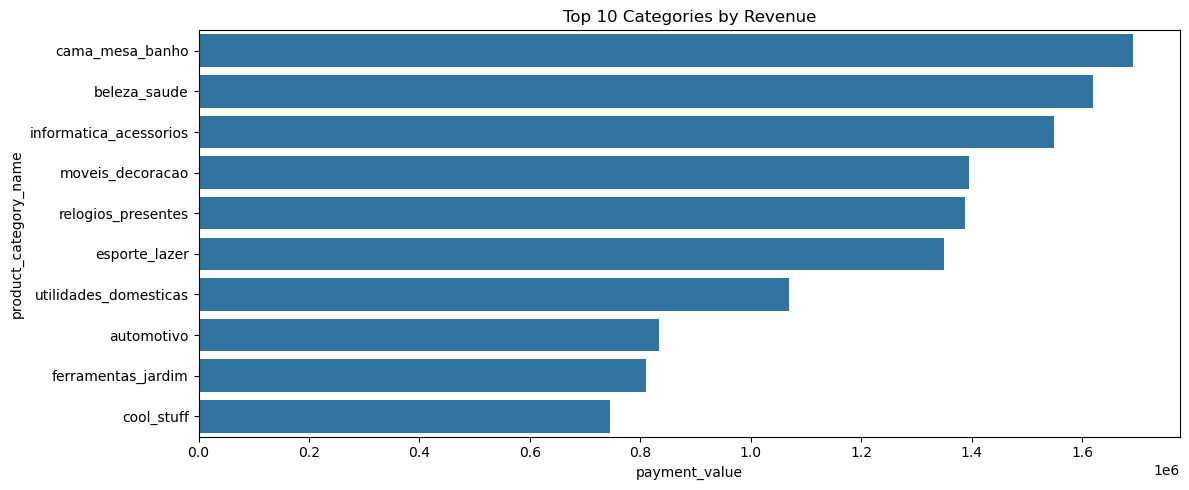

In [2]:
top_categories = master.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_categories, x='payment_value', y='product_category_name')
plt.title('Top 10 Categories by Revenue')
plt.tight_layout()
plt.show()

In [3]:
order_value = master.groupby('order_id')['payment_value'].sum()
print(f"Average Order Value: R$ {order_value.mean():.2f}")
print(f"Median Order Value: R$ {order_value.median():.2f}")
print(f"Max Order Value: R$ {order_value.max():.2f}")

Average Order Value: R$ 204.98
Median Order Value: R$ 109.50
Max Order Value: R$ 109312.64


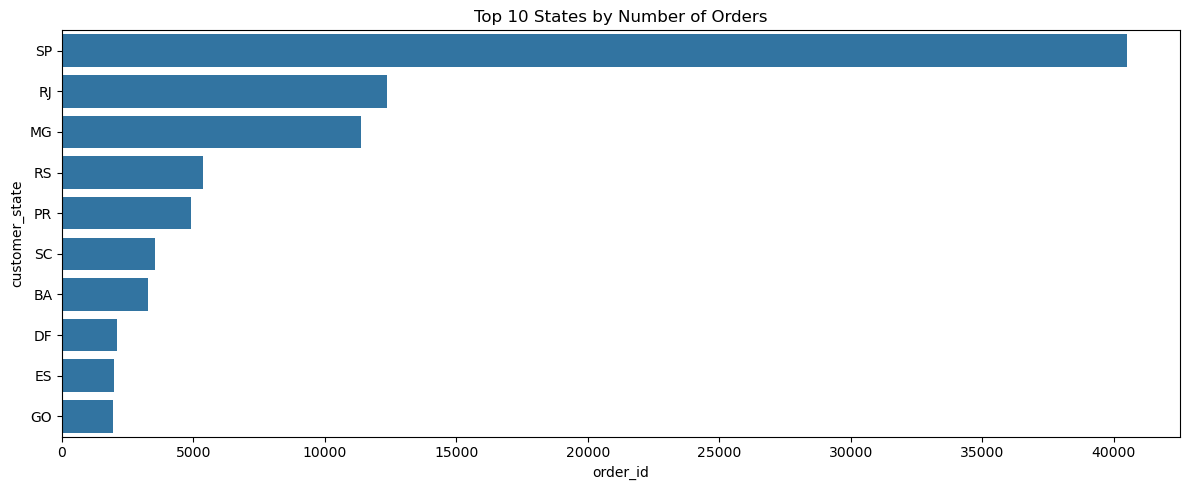

In [4]:
state_orders = master.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=state_orders, x='order_id', y='customer_state')
plt.title('Top 10 States by Number of Orders')
plt.tight_layout()
plt.show()

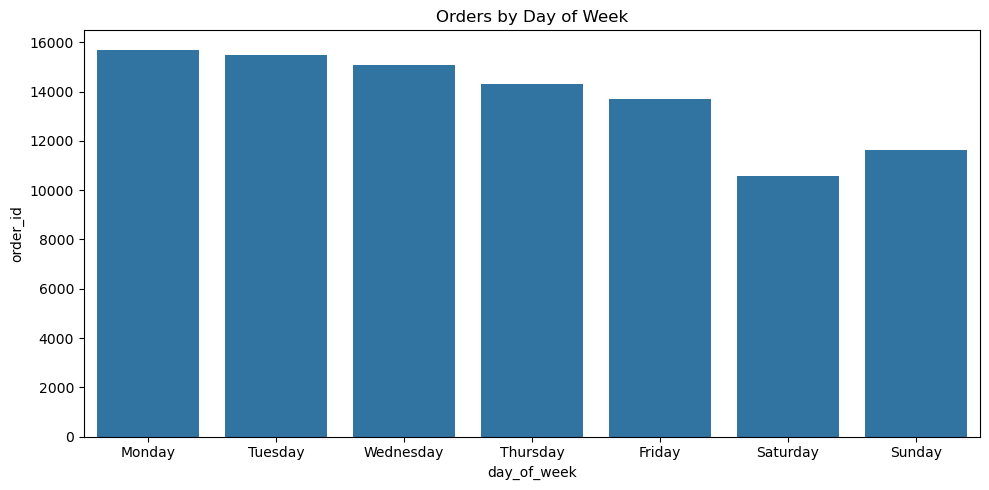

In [5]:
master['day_of_week'] = master['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_orders = master.groupby('day_of_week')['order_id'].nunique().reindex(day_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=day_orders, x='day_of_week', y='order_id')
plt.title('Orders by Day of Week')
plt.tight_layout()
plt.show()

Key Insights:

1. Revenue grew steadily from 2016 to 2018 indicating strong business scaling
2. Bed/bath, health/beauty and computer accessories are the top 3 revenue categories
3. Average order value (R$204) is almost double the median (R$109) suggesting a small number of high value orders skew the average
4. São Paulo, Rio de Janeiro and Minas Gerais account for the majority of orders reflecting Brazil population distribution
5. Monday is the peak ordering day suggesting customers plan purchases at the start of the week